### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
#import the required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('./data/coupons.csv')

In [6]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

In [7]:
# Check the columns with null values
data.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


In [8]:
# analysing the data set for different values and the count for columns
data_dest_counts = data['destination'].value_counts()
display(data_dest_counts)

data_weather_counts = data['weather'].value_counts()
display(data_weather_counts)

data_time_counts = data['time'].value_counts()
display(data_time_counts)

data_income_counts = data['income'].value_counts()
display(data_income_counts)

data_restaurant_counts = data['RestaurantLessThan20'].value_counts()
display(data_restaurant_counts)

data_direction_same = data['direction_same'].value_counts()
display(data_direction_same)

data_direction_opp = data['direction_opp'].value_counts()
display(data_direction_opp)

data_coupon_counts = data['coupon'].value_counts()
display(data_coupon_counts)



,count
destination,
No Urgent Place,6283
Home,3237
Work,3164


,count
weather,
Sunny,10069
Snowy,1405
Rainy,1210


,count
time,
6PM,3230
7AM,3164
10AM,2275
2PM,2009
10PM,2006


,count
income,
$25000 - $37499,2013
$12500 - $24999,1831
$37500 - $49999,1805
$100000 or More,1736
$50000 - $62499,1659
Less than $12500,1042
$87500 - $99999,895
$75000 - $87499,857
$62500 - $74999,846


,count
RestaurantLessThan20,
1~3,5376
4~8,3580
less1,2093
gt8,1285
never,220


,count
direction_same,
0,9960
1,2724


,count
direction_opp,
1,9960
0,2724


,count
coupon,
Coffee House,3996
Restaurant(<20),2786
Carry out & Take away,2393
Bar,2017
Restaurant(20-50),1492


In [9]:
#Mapping columns to convert into numeric column in the dataframe to make the comparisons easier.
salary_mapping = {
    'Less than $12500': 12499,
    '$12500 - $24999': 20000,
    '$25000 - $37499': 30000,
    '$37500 - $49999': 40000,
    '$50000 - $62499': 60000,
    '$62500 - $74999': 70000,
    '$75000 - $87499': 80000,
    '$87500 - $99999': 90000,
    '$100000 or More': 100000
}

data['salary_numeric'] = data['income'].map(salary_mapping)
data['salary_numeric'].unique()

array([ 40000,  70000,  20000,  80000,  60000,  30000, 100000,  90000,
        12499])

3. Decide what to do about your missing data -- drop, replace, other...

In [10]:
#Correct the passenger column spelling
data.rename(columns={'passanger':'passenger'},inplace=True)

In [11]:
#Drop the car column as it is not useful as 99% of the values are missing or null
data = data.drop(columns=['car'])

In [12]:

# Map the age column to appropriate age and create a age column as number data type
age_mapping = {
    'below21': 20,
    '21': 21,
    '26': 26,
    '31': 31,
    '36': 36,
    '41': 41,
    '46':46,
    '50plus':51
    }
data['numeric_Age']  = data['age'].map(age_mapping)

display(data['age'].value_counts())

print(data[data['numeric_Age'] > 50].count()['age'])


,count
age,
21,2653
26,2559
31,2039
50plus,1788
36,1319
41,1093
46,686
below21,547


1788


In [13]:

# Replace nan in  frequency columns to Unknown

frequency_cols = ['Bar','CoffeeHouse','CarryAway','Restaurant20To50','RestaurantLessThan20']
for col in frequency_cols:
    data[col] = data[col].fillna('Unknown')



In [14]:
 # Map the frequency column values to numeric data for easier interpretations and querying

freq_colvalue_mapping = {
     'Unknown' : None,
     'less1' : 0.9,
     '1~3' : 2,
     '4~8' : 6,
     'gt8' : 9,
     'never' : 0
 }

data['bar_numeric'] = data['Bar'].map(freq_colvalue_mapping)
data['coffee_numeric'] = data['CoffeeHouse'].map(freq_colvalue_mapping)
data['carry_numeric'] = data['CarryAway'].map(freq_colvalue_mapping)
data['restaurant20_numeric'] = data['Restaurant20To50'].map(freq_colvalue_mapping)
data['restaurant_numeric'] = data['RestaurantLessThan20'].map(freq_colvalue_mapping)



In [15]:
# check for duplicates
data.duplicated().sum()
print("Duplicate rows : " + str(data.duplicated().sum()))

# delete duplicate rows
data = data.drop_duplicates()


Duplicate rows : 74


4. What proportion of the total observations chose to accept the coupon?



In [21]:
# total observations in the data set
total_observations = data['Y'].count()
print("Total observations:" + str(total_observations))

#Accepted coupons in the data set
accepted_count = data[data['Y'] == 1]['Y'].count()
print("Accepted count:" + str(accepted_count))

accepted_proportion = accepted_count / total_observations
print("Accepted Proportion : " + str(round((accepted_proportion * 100),2)) + "%")

accepted_proportion_using_mean = data['Y'].mean()
print("Accepted Proportion : " + str(round((accepted_proportion*100),2)) + "%" )

# More than half of the total observations accepted the coupons


Total observations:12610
Accepted count:7157
Accepted Proportion : 56.76%
Accepted Proportion : 56.76%


# More than half of the total observations accepted the coupons.

5. Use a bar plot to visualize the `coupon` column.

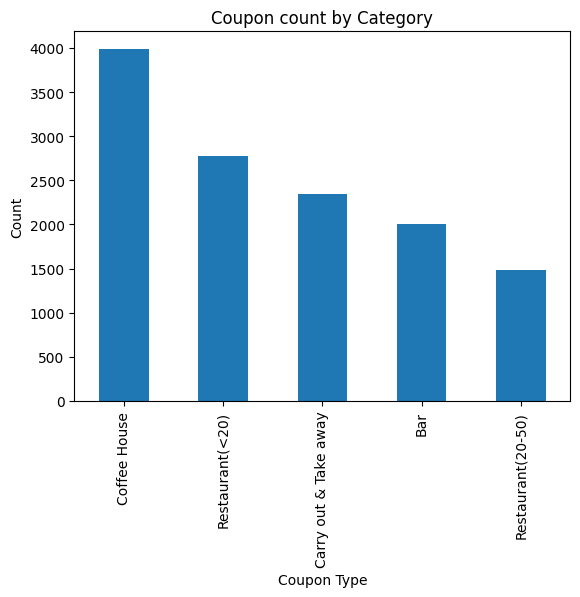

In [22]:
data['coupon'].value_counts().plot(kind='bar',title='Coupon count by Category')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.show()
# More Coffee house coupons sent thatn others

6. Use a histogram to visualize the temperature column.

,count
temperature,
80,6475
55,3830
30,2305


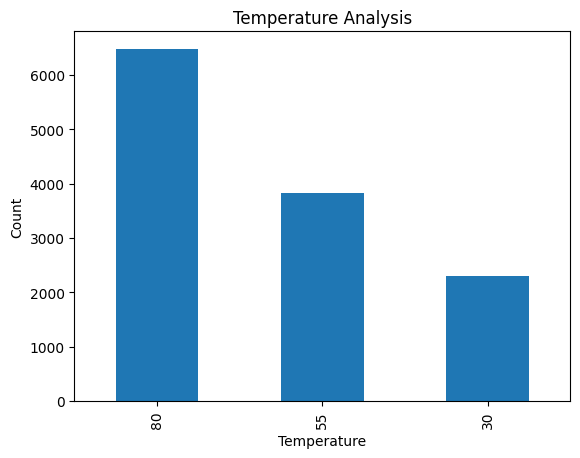

In [23]:
display(data['temperature'].value_counts())
data['temperature'].value_counts().plot(kind = 'bar', title = 'Temperature Analysis')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()


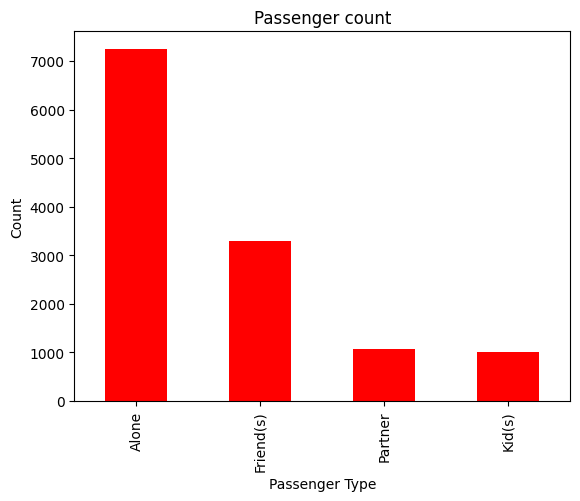

In [24]:
#Visualizing the passenger column using a bar plot
data['passenger'].value_counts().plot(kind='bar',title='Passenger count',color='red')
plt.xlabel('Passenger Type')
plt.ylabel('Count')
plt.show()


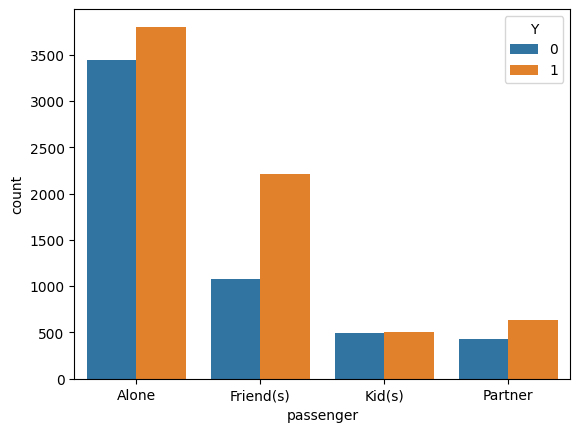

In [20]:
#using seaborn visualizing the passenger column with the output column Y
sns.countplot(data=data,x='passenger',hue='Y')
plt.show()


Acceptance Rate of coupons if passenger type Friend(s) is 67.31%


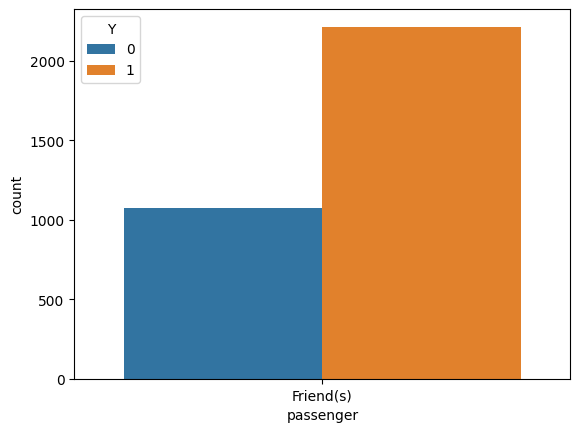

In [27]:
# Acceptance rate for passenger type as 'Friend(s)'

total_friend_count = data[data['passenger'] == 'Friend(s)']['passenger'].count()
accepted_friend_count = data[(data['passenger'] == 'Friend(s)') & (data['Y'] == 1)]['Y'].count()

passenger_friend_df = data[data['passenger'] == "Friend(s)"]

acceptance_rate_friend = passenger_friend_df['Y'].mean()
print('Acceptance Rate of coupons if passenger type Friend(s) is ' + str(round((acceptance_rate_friend*100),2)) + '%')

sns.countplot(data=passenger_friend_df,x='passenger',hue='Y')
plt.show()



#Coupon acceptance rate if the passenger type Friend(s) is 67.31%. That is more than 2/3rd of the drivers with friends accepted the coupon sent.

['Rainy' 'Snowy']
Acceptance Rate of coupons if weather is rainy or snowy is 46.79%


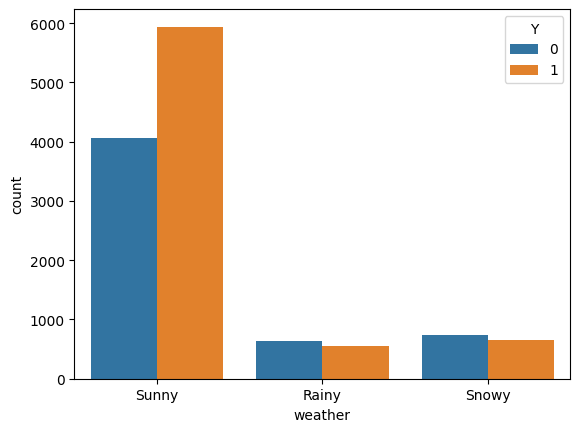

In [28]:
# Accepted rate on a rainy and snowy weather day
weather_extreme_df = data[(data['weather'] == 'Rainy') |(data['weather'] == 'Snowy')]
print(weather_extreme_df['weather'].unique())

accepted_rate_weather_extreme = weather_extreme_df['Y'].mean()
print('Acceptance Rate of coupons if weather is rainy or snowy is ' + str(round((accepted_rate_weather_extreme*100),2)) + '%')

data.groupby(data['weather'])['Y'].value_counts()
sns.countplot(data=data,x='weather',hue='Y')
plt.show()

#For rainy or snowy weather the rate of coupon acceptance is less than 50% i.e the drivers are more likely to reject the coupons than accept it.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


Number of bar coupons are : 2010


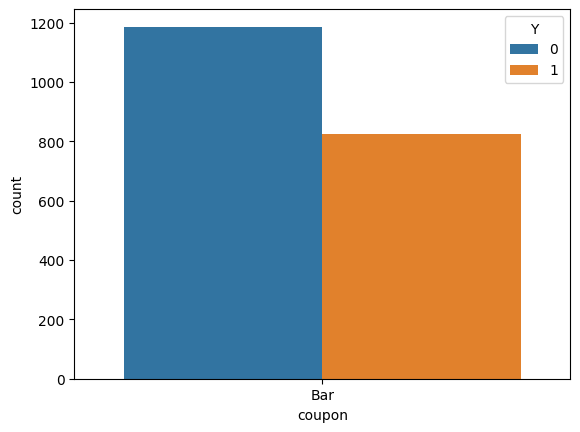

In [29]:
data_bar = data[data['coupon'] == 'Bar']
print('Number of bar coupons are : ' + str(data_bar['coupon'].count()))

sns.countplot(data=data_bar,x='coupon',hue='Y')
plt.show()

2. What proportion of bar coupons were accepted?


In [30]:
accepted_bar_coupon_rate = data_bar['Y'].mean()
print('Accepted bar coupon : ' + str(round((accepted_bar_coupon_rate*100),2)) + '%')

Accepted bar coupon : 41.0%


# Drivers acceptance for Bar coupons is less than half about 41%.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


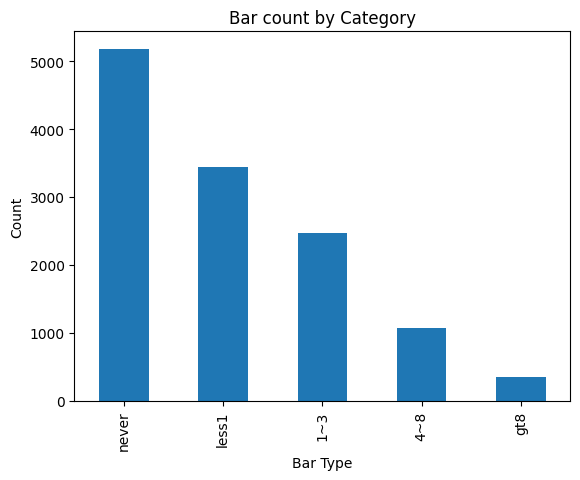

Less than 3 : [0.  0.9 2. ]
Acceptance rate for drivers who went to Bar less than 3 times is : 56.12%
[9. 6.]


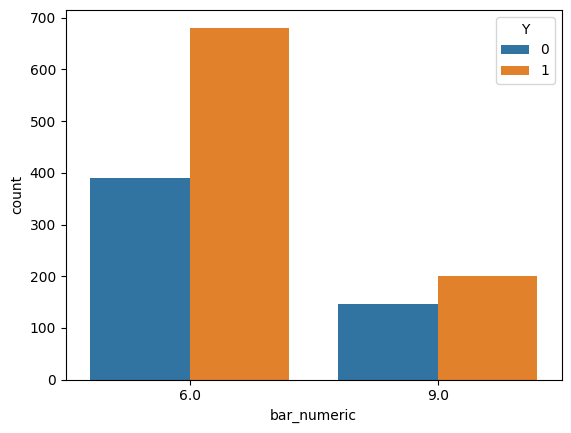

Acceptance rate for drivers who went to Bar more than 3 times is : 62.16%


In [31]:
data_bar_freq_df = data[data['bar_numeric'] >= 0 ]
data_bar_freq_df['Bar'].value_counts().plot(kind='bar',title='Bar count by Category')
plt.xlabel('Bar Type')
plt.ylabel('Count')
plt.show()

data_bar_freq_df = data_bar_freq_df.dropna(subset=['bar_numeric'])

data_bar_lt3_df = data_bar_freq_df[data_bar_freq_df['bar_numeric'] < 3]
print('Less than 3 : '+ str(data_bar_lt3_df['bar_numeric'].unique()))

acceptance_rate_lessthan3 = data_bar_lt3_df['Y'].mean()
print('Acceptance rate for drivers who went to Bar less than 3 times is : ' + str(round((acceptance_rate_lessthan3*100),2)) + '%')

data_bar_mt3_df = data_bar_freq_df[data_bar_freq_df['bar_numeric'] >= 3]
print(data_bar_mt3_df['bar_numeric'].unique())

sns.countplot(data=data_bar_mt3_df,x='bar_numeric',hue ='Y')
plt.show()

acceptance_rate_morethan3 = data_bar_mt3_df['Y'].mean()
print('Acceptance rate for drivers who went to Bar more than 3 times is : ' + str(round((acceptance_rate_morethan3*100),2)) + '%')


#Drivers who went more than 3 times to a bar are more likely to accept the coupons.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [33]:

data_without_null_df = data.dropna(subset = ['bar_numeric'])

data_bar_freq_1_age_gt_25_df = data_without_null_df[(data_without_null_df['bar_numeric'] > 1)  & (data_without_null_df['numeric_Age'] > 25)]

data_bar_others_df = data_without_null_df[~((data_without_null_df['bar_numeric'] >= 1)  & (data_without_null_df['numeric_Age'] > 25))]

acceptance_rate_bar_freq_1_age_gt_25 = data_bar_freq_1_age_gt_25_df['Y'].mean()
print('Acceptance rate for drivers who went to Bar more than once a month and are over the age of 25 is : ' + str(round((acceptance_rate_bar_freq_1_age_gt_25*100),2)) + '%')

acceptance_rate_bar_others = data_bar_others_df['Y'].mean()
print('Acceptance rate for all the other drivers : ' + str(round((acceptance_rate_bar_others*100),2)) + '%')


Acceptance rate for drivers who went to Bar more than once a month and are over the age of 25 is : 62.02%
Acceptance rate for all the other drivers : 55.32%


# Drivers who went to bar more than once a month and over the age to 25 are more likely to accept the coupons than others.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [34]:

data_atl_1_notkid_occ_other_df = data_without_null_df[(data_without_null_df['passenger'] != 'Kid(s)') & (data_without_null_df['occupation'] != 'Farming Fishing & Forestry')]
data_all_others_df = data_without_null_df[~((data_without_null_df['passenger'] != 'Kid(s)') & (data_without_null_df['occupation'] != 'Farming Fishing & Forestry'))]

acceptance_rate_atl_1_notkid_occ_other_df = data_atl_1_notkid_occ_other_df['Y'].mean()
print('Acceptance rate for drivers who went to Bar more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry is : ' + str(round((acceptance_rate_atl_1_notkid_occ_other_df*100),2)) + '%')

acceptance_all_others_df = data_all_others_df['Y'].mean()
print('Acceptance rate for all the other drivers : ' + str(round((acceptance_all_others_df*100),2)) + '%')



Acceptance rate for drivers who went to Bar more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry is : 57.39%
Acceptance rate for all the other drivers : 50.2%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [35]:

data_mt1_pas_not_kid_not_widowed_df = data_without_null_df[(data_without_null_df['bar_numeric'] > 1) & (data_without_null_df['passenger'] != 'Kid(s)') & (data_without_null_df['passenger'] != 'Widowed') ]
print(data_mt1_pas_not_kid_not_widowed_df['passenger'].unique())
acceptance_rate_mt1_pas_not_kid_not_widowed  = data_mt1_pas_not_kid_not_widowed_df['Y'].mean()
print('Acceptance rate for drivers who went to Bar more than once a month, had passengers that were not a kid and were not widowed is : ' + str(round((acceptance_rate_mt1_pas_not_kid_not_widowed*100),2)) + '%')

data_mt1_age_lt30_df = data_without_null_df[(data_without_null_df['bar_numeric'] > 1) & (data_without_null_df['numeric_Age'] < 30) ]
print(data_mt1_age_lt30_df['numeric_Age'].unique())

acceptance_mt1_age_lt30 = data_mt1_age_lt30_df['Y'].mean()
print('Acceptance rate for drivers who went to Bar more than once a month and are under the age of 30 is : ' + str(round((acceptance_mt1_age_lt30*100),2)) + '%')

data_mt4_income_lt50k_df = data_without_null_df[(data_without_null_df['restaurant_numeric'] > 4) & (data_without_null_df['salary_numeric'] < 50000) ]
print(data_mt4_income_lt50k_df['salary_numeric'].unique())

acceptance_mt4_income_lt50k = data_mt4_income_lt50k_df['Y'].mean()
print('Acceptance rate for drivers who went to cheap restaurants more than 4 times a month and income is less than 50K is : ' + str(round((acceptance_mt4_income_lt50k*100),2)) + '%')




['Alone' 'Friend(s)' 'Partner']
Acceptance rate for drivers who went to Bar more than once a month, had passengers that were not a kid and were not widowed is : 62.23%
[21 26 20]
Acceptance rate for drivers who went to Bar more than once a month and are under the age of 30 is : 62.75%
[40000 30000 20000 12499]
Acceptance rate for drivers who went to cheap restaurants more than 4 times a month and income is less than 50K is : 60.21%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

# The overall acceptance rate for drivers who received coupon as 'Bar' is 41%.
# The acceptance rate for drivers who go less than 3 times a month is less when compared to drivers who go more than 3 times in a month.
#Drivers who went to bar more than once a month and over the age to 25 are more likely to accept the coupons than others.

#Acceptance rate for drivers who went to Bar more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry is more when compared to the acceptance rate for all the other drivers.

#Acceptance rate for drivers who went to Bar more than once a month, had passengers that were not a kid and were not widowed is : 62.23%

#Acceptance rate for drivers who went to Bar more than once a month and are under the age of 30 is : 62.75%

#Acceptance rate for drivers who went to cheap restaurants more than 4 times a month and income is less than 50K is : 60.21%

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Number of coffee coupons are : 3989


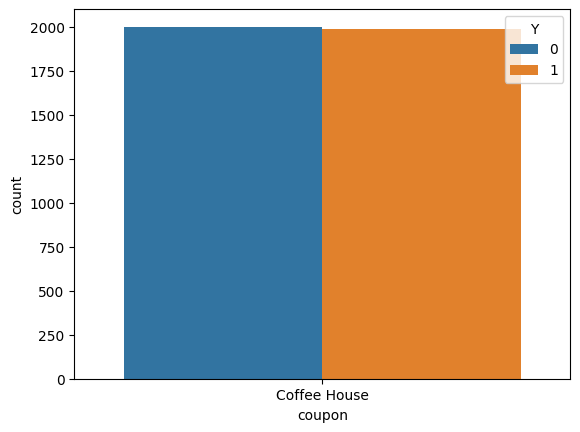

Acceptance rate for coffee coupons is : 49.86%
Acceptance rate for all the other coupons is : 59.95%


In [36]:
#Compare acceptance rate of Coffee House as coupon with all other coupons

data_coffee_df = data[data['coupon'] == 'Coffee House']

print('Number of coffee coupons are : ' + str(data_coffee_df['coupon'].count()))
sns.countplot(data=data_coffee_df,x='coupon',hue='Y')
plt.show()

acceptance_rate_coffee = data_coffee_df['Y'].mean()
print('Acceptance rate for coffee coupons is : ' + str(round((acceptance_rate_coffee*100),2)) + '%')

data_coffee_others_df = data[~(data['coupon'] == 'Coffee House')]
acceptance_rate_coffee_others = data_coffee_others_df['Y'].mean()
print('Acceptance rate for all the other coupons is : ' + str(round((acceptance_rate_coffee_others*100),2)) + '%')


In [41]:
# Remove the drivers whose frequency to Coffee house is Unknown or null

#Compare acceptance rate of drivers who received Coffee House coupon and passenger as partner with all others

data_freq_coffee_df = data_coffee_df[data_coffee_df['coffee_numeric'] > 0 ]

data_coff_wpartner_df = data_freq_coffee_df[(data_freq_coffee_df['passenger']=='Partner')]
data_coff_wopartner_df = data_freq_coffee_df[~(data_freq_coffee_df['passenger']=='Partner')]

acceptance_rate_for_CC_with_partner = data_coff_wpartner_df['Y'].mean()
print('Acceptance rate for drivers who received Coffee House coupons and had passengers that was a partner is : ' + str(round((acceptance_rate_for_CC_with_partner*100),2)) + '%')

acceptance_rate_for_CC_with_others = data_coff_wopartner_df['Y'].mean()
print('Acceptance rate for drivers who received Coffee House coupons and had passengers that were not a partner is : ' + str(round((acceptance_rate_for_CC_with_others*100),2)) + '%')



Acceptance rate for drivers who received Coffee House coupons and had passengers that was a partner is : 66.81%
Acceptance rate for drivers who received Coffee House coupons and had passengers that were not a partner is : 58.96%


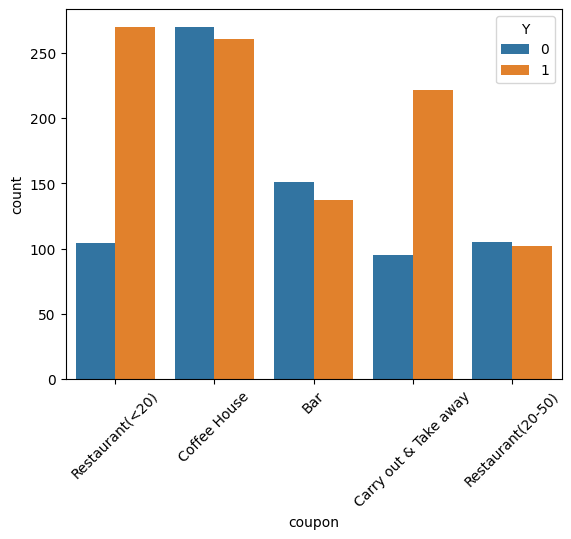

Acceptance rate for drivers who received Coffee House coupons and had income greater than 100K is : 49.15%
Acceptance rate for drivers who had income greater than 100K and coupon other than Coffee House is : 61.64%
Acceptance rate for drivers who received Coffee House coupon, had income greater than 100K and had passengers that were a kid is : 51.85%
Acceptance rate for drivers who received Coffee House coupon, had income greater than 100K and had passengers that were not a kid is : 57.87%


In [42]:
#Compare drivers whose income greater than 100k and coupon received is coffeehouse with other coupons.

data_income_gt_100k_df = data[data['salary_numeric'] >= 100000]
sns.countplot(data=data_income_gt_100k_df,x='coupon',hue='Y')
plt.xticks(rotation=45)
plt.show()

data_income_gt_100k_CC_df = data_income_gt_100k_df[data_income_gt_100k_df['coupon'] == 'Coffee House']
acceptance_rate_income_gt_100k_CC = data_income_gt_100k_CC_df['Y'].mean()
print('Acceptance rate for drivers who received Coffee House coupons and had income greater than 100K is : ' + str(round((acceptance_rate_income_gt_100k_CC*100),2)) + '%')

data_income_gt_100k_others_df = data_income_gt_100k_df[~(data_income_gt_100k_df['coupon'] == 'Coffee House')]
acceptance_rate_income_gt_100k_others = data_income_gt_100k_others_df['Y'].mean()
print('Acceptance rate for drivers who had income greater than 100K and coupon other than Coffee House is : ' + str(round((acceptance_rate_income_gt_100k_others*100),2)) + '%')

#Compare drivers whose income greater than 100k and coupon received is coffeehouse and passenger as Kid(s) with others.

data_income_gt_100k_CC_wkids_df = data_income_gt_100k_df[(data_income_gt_100k_df['coupon'] == 'Coffee House') & (data_income_gt_100k_df['passenger'] == 'Kid(s)')]
acceptance_rate_income_gt_100k_CC_wkids = data_income_gt_100k_CC_wkids_df['Y'].mean()
print('Acceptance rate for drivers who received Coffee House coupon, had income greater than 100K and had passengers that were a kid is : ' + str(round((acceptance_rate_income_gt_100k_CC_wkids*100),2)) + '%')

data_income_gt_100k_CC_others_df = data_income_gt_100k_df[~((data_income_gt_100k_df['coupon'] == 'Coffee House') & (data_income_gt_100k_df['passenger'] == 'Kid(s)'))]
acceptance_rate_income_gt_100k_CC_others = data_income_gt_100k_CC_others_df['Y'].mean()
print('Acceptance rate for drivers who received Coffee House coupon, had income greater than 100K and had passengers that were not a kid is : ' + str(round((acceptance_rate_income_gt_100k_CC_others*100),2)) + '%'  )




In [43]:
#Compare drivers with income greater than 100k and received coupon for Carry out and Take away with others.
data_income_gt_100k_CTC_df = data_income_gt_100k_df[data_income_gt_100k_df['coupon'] == 'Carry out & Take away']
acceptance_rate_income_gt_100k_CTC = data_income_gt_100k_CTC_df['Y'].mean()
print('Acceptance rate for drivers who received Carryout and Take away coupons and had income greater than 100K is : ' + str(round((acceptance_rate_income_gt_100k_CTC*100),2)) + '%')

data_income_gt_100k_CTCothers_df = data_income_gt_100k_df[~(data_income_gt_100k_df['coupon'] == 'Carry Out & Take away')]
acceptance_rate_income_gt_100k_ctcothers = data_income_gt_100k_CTCothers_df['Y'].mean()
print('Acceptance rate for drivers who had income greater than 100K and coupon other than Carry out and take away : ' + str(round((acceptance_rate_income_gt_100k_ctcothers*100),2)) + '%')


Acceptance rate for drivers who received Carryout and Take away coupons and had income greater than 100K is : 70.03%
Acceptance rate for drivers who had income greater than 100K and coupon other than Carry out and take away : 57.78%


,count
passenger,
Alone,7248
Friend(s),3292
Partner,1069
Kid(s),1001


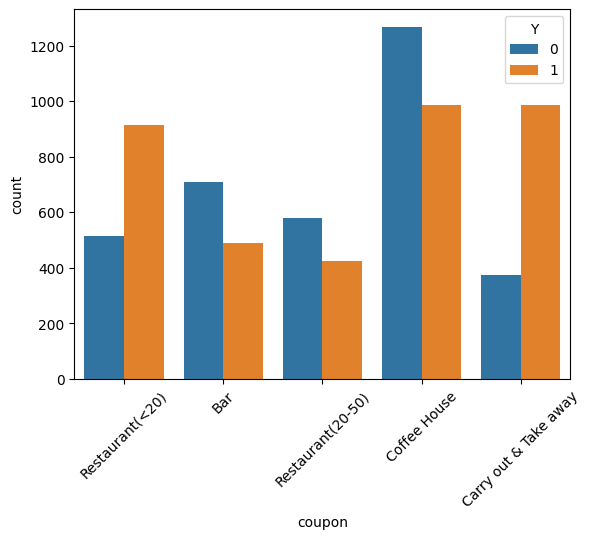

Acceptance rate for drivers who received Carry out and take away coupons and had income greater than 100K is : 71.43%
Acceptance rate for drivers who were Alone and other than Carry out & Take away and income > 100k : 51.97%


In [44]:
display(data['passenger'].value_counts())

data_alone_df = data[data['passenger'] == 'Alone']

sns.countplot(data=data_alone_df,x='coupon',hue='Y')
plt.xticks(rotation=45)
plt.show()

# Compare drivers who are Alone with income greater than 100k and coupon received is Carry Out and Take away with others.

data_alone_CTC_income_gt_100k_df = data_alone_df[(data_alone_df['coupon'] == 'Carry out & Take away') & (data_alone_df['salary_numeric'] >= 100000)]
acceptance_rate_alone_CTC_gt_100k = data_alone_CTC_income_gt_100k_df['Y'].mean()
print('Acceptance rate for drivers who received Carry out and take away coupons and had income greater than 100K is : ' + str(round((acceptance_rate_alone_CTC_gt_100k*100),2)) + '%')

data_alone_others_df = data_alone_df[~((data_alone_df['coupon'] == 'Carry out & Take away') & (data_alone_df['salary_numeric'] >= 100000))]
acceptance_rate_alone_others= data_alone_others_df['Y'].mean()
print('Acceptance rate for drivers who were Alone and other than Carry out & Take away and income > 100k : ' + str(round((acceptance_rate_alone_others*100),2)) + '%')


#Acceptance rate for drivers who received Coffee house coupon is close to 50% and acceptance rate for others who received coupons other than coffee is close to 60%.

#Acceptance rate for drivers who went to Coffee House and had passengers that was a partner is : 66.81%

#Acceptance rate for drivers who went to Coffee House and had passengers that were not a partner is : 58.96%

#Acceptance rate for drivers who went to Coffee House and had income greater than 100K is : 49.15%

#Acceptance rate for drivers who had income greater than 100K and coupon other than Coffee House is : 61.64%

#Acceptance rate for drivers who received Coffee House coupon, had income greater than 100K and had passengers that were a kid is : 51.85%

#Acceptance rate for drivers who went to Carry out and take away and had income greater than 100K is : 71.43%

#Acceptance rate for drivers who were Alone and other than Carry out & Take away and income > 100k : 51.97%

#